In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def get_price_plots(FILENAME: str, day: int) -> None:
    df = pd.read_csv(FILENAME, delimiter=';')
    root = df[df['product'] == 'INTARIAN_PEPPER_ROOT']
    osmium = df[df['product'] == 'ASH_COATED_OSMIUM']
    
    price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
    for col in price_cols:
        osmium[col] = osmium[col].replace(0, pd.NA)
        root[col] = root[col].replace(0, pd.NA)
    
    osmium[price_cols] = osmium[osmium.columns.intersection(price_cols)].ffill()
    root[price_cols] = root[root.columns.intersection(price_cols)].ffill()

    fig, ax = plt.subplots(figsize=(8, 5))
    plt.title(f'Day {day} Root Prices')
    ax.grid()
    ax.plot(root['timestamp'], root['bid_price_1'], color='red', label='Root Bid Price 1', alpha=0.5)

    ax.plot(root['timestamp'], root['ask_price_1'], color='green', label='Root Ask Price 1', alpha=0.5)

    ax.plot(root['timestamp'], root['mid_price'], linestyle='dashed', color='grey', label='Root Mid Price')
    plt.legend(loc='lower right')

    fig, ax = plt.subplots(figsize=(8, 5))
    plt.title(f'Day {day} Osmium Prices')
    ax.grid()
    ax.plot(osmium['timestamp'], osmium['bid_price_1'], color='red', label='Osmium Bid Price 1', alpha=0.5)

    ax.plot(osmium['timestamp'], osmium['ask_price_1'], color='green', label='Osmium Ask Price 1', alpha=0.5)

    ax.plot(osmium['timestamp'], osmium['mid_price'], linestyle='dashed', color='grey', label='Osmium Mid Price')
    plt.legend(loc='lower right')

C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\4243613686.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  osmium[col] = osmium[col].replace(0, pd.NA)
C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\4243613686.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  root[col] = root[col].replace(0, pd.NA)
C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\4243613686.py:11: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call resu

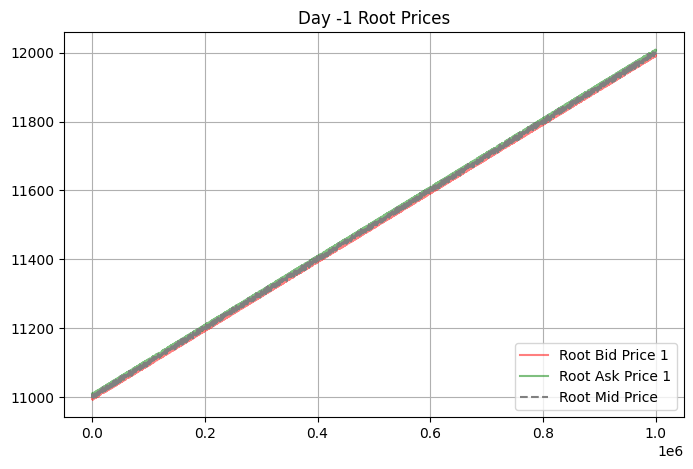

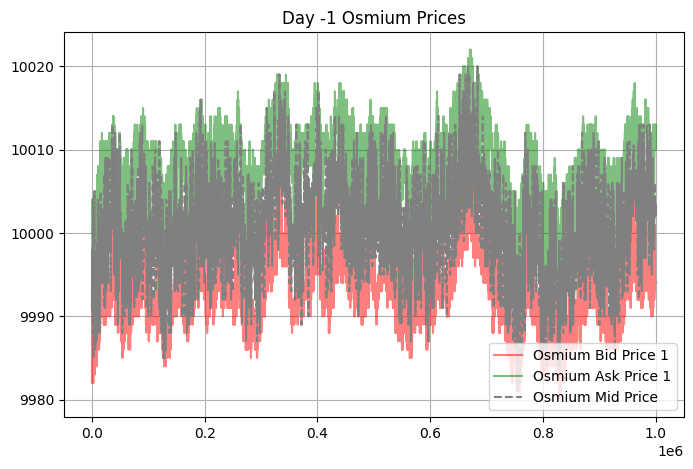

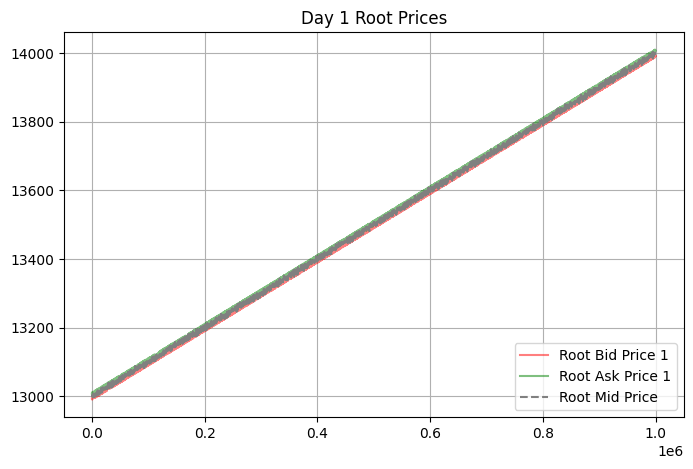

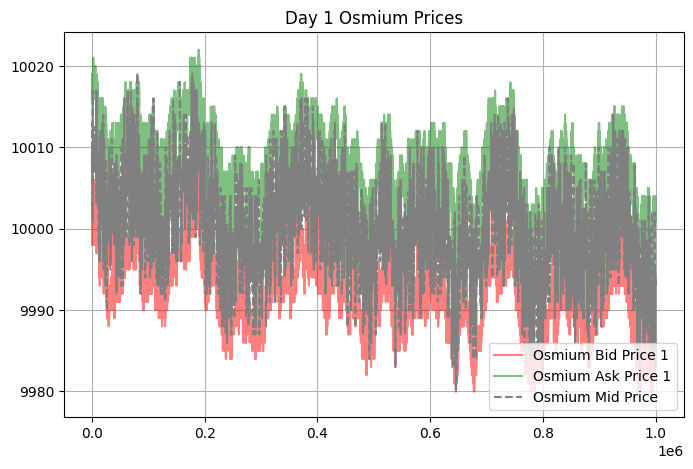

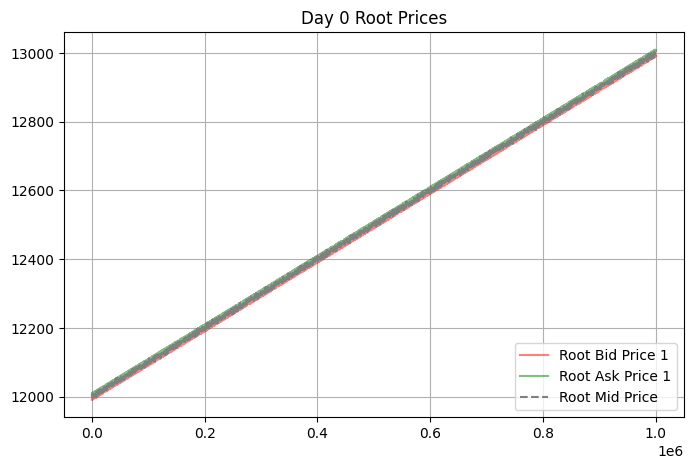

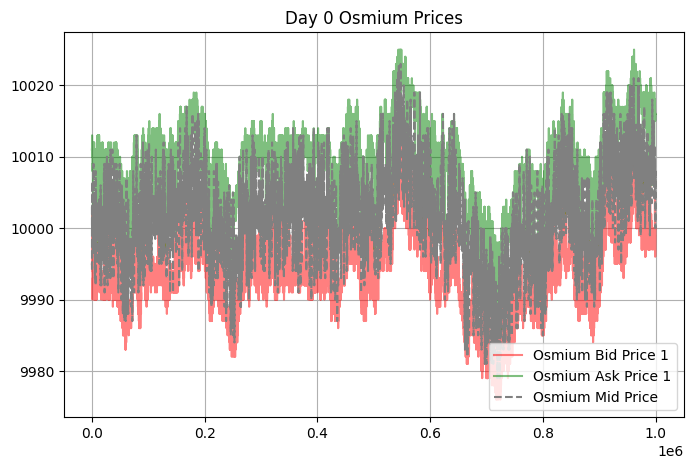

In [6]:
files = {-1: '../Round 2/Data/prices_round_2_day_-1.csv', 
         1: '../Round 2/Data/prices_round_2_day_1.csv', 
         0: '../Round 2/Data/prices_round_2_day_0.csv'}

for key, val in files.items():
    get_price_plots(FILENAME=val, day=key)

C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\3277843650.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  osmium[price_cols] = osmium[osmium.columns.intersection(price_cols)].ffill()


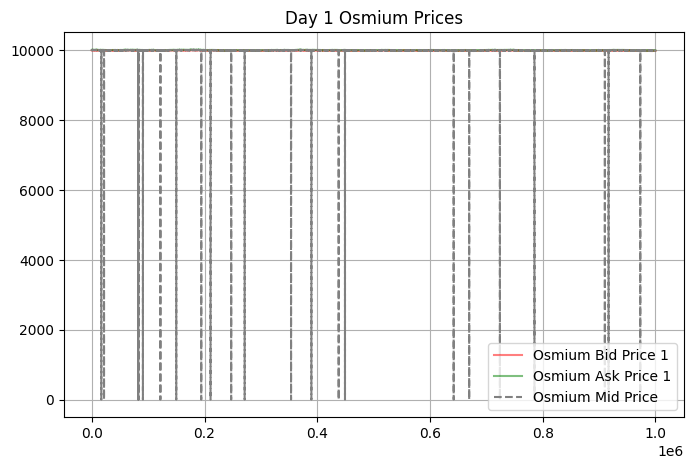

In [7]:
df = pd.read_csv('../Round 2/Data/prices_round_2_day_1.csv', delimiter=';')
osmium = df[df['product'] == 'ASH_COATED_OSMIUM']

price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
# for col in price_cols:
#     osmium[col] = osmium[col].replace(0, pd.NA)

osmium[price_cols] = osmium[osmium.columns.intersection(price_cols)].ffill()

fig, ax = plt.subplots(figsize=(8, 5))
plt.title('Day 1 Osmium Prices')
ax.grid()
ax.plot(osmium['timestamp'], osmium['bid_price_1'], color='red', label='Osmium Bid Price 1', alpha=0.5)

ax.plot(osmium['timestamp'], osmium['ask_price_1'], color='green', label='Osmium Ask Price 1', alpha=0.5)

ax.plot(osmium['timestamp'], osmium['mid_price'], linestyle='dashed', color='grey', label='Osmium Mid Price')
plt.legend(loc='lower right')

C:\Users\wfpin\AppData\Local\Temp\ipykernel_10380\1771031169.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  roots[price_cols] = roots[roots.columns.intersection(price_cols)].ffill()


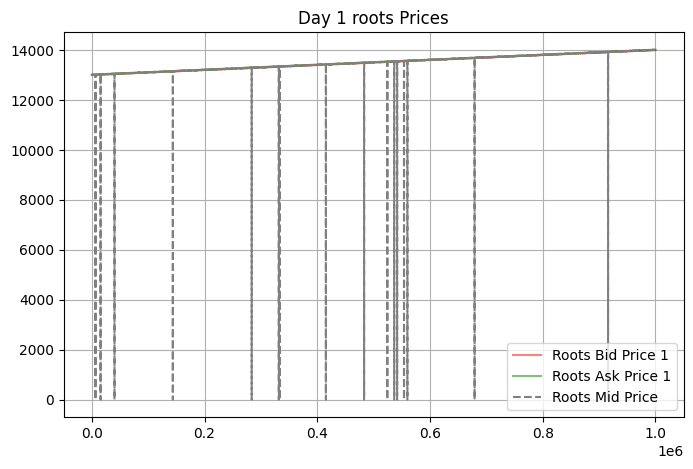

In [8]:
df = pd.read_csv('../Round 2/Data/prices_round_2_day_1.csv', delimiter=';')
roots = df[df['product'] == 'INTARIAN_PEPPER_ROOT']

price_cols = ['bid_price_1', 'ask_price_1', 'mid_price']
# for col in price_cols:
#     roots[col] = roots[col].replace(0, pd.NA)

roots[price_cols] = roots[roots.columns.intersection(price_cols)].ffill()

fig, ax = plt.subplots(figsize=(8, 5))
plt.title('Day 1 roots Prices')
ax.grid()
ax.plot(roots['timestamp'], roots['bid_price_1'], color='red', label='Roots Bid Price 1', alpha=0.5)

ax.plot(roots['timestamp'], roots['ask_price_1'], color='green', label='Roots Ask Price 1', alpha=0.5)

ax.plot(roots['timestamp'], roots['mid_price'], linestyle='dashed', color='grey', label='Roots Mid Price')
plt.legend(loc='lower right')

In [ ]:
import numpy as np

class KalmanFilter(object):
    def __init__(self, F = None, Z = None, Q = None, eps = None, P = None, x0 = None):

        if(F is None or H is None):
            raise ValueError("Set proper system dynamics.")

        self.n = F.shape[1]
        self.m = H.shape[1]

        # The transition matrix, set F = 1 - like a random walk
        self.F = F

        # Observation model, set Z = 1
        self.Z = Z

        # Process noise - Hidden Pattern
        self.Q = np.eye(self.n) if Q is None else Q

        # Measurement noise
        self.eps = np.eye(self.n) if R is None else R

        # Error covariance
        self.P = np.eye(self.n) if P is None else P

        # state estimate
        self.x = np.zeros((self.n, 1)) if x0 is None else x0

    def predict(self, u = 0):
        self.x = np.dot(self.F, self.x) + np.dot(self.B, u)
        self.P = np.dot(np.dot(self.F, self.P), self.F.T) + self.Q
        return self.x

    def update(self, z):
        y = z - np.dot(self.H, self.x)
        S = self.R + np.dot(self.H, np.dot(self.P, self.H.T))
        K = np.dot(np.dot(self.P, self.H.T), np.linalg.inv(S))
        self.x = self.x + np.dot(K, y)
        I = np.eye(self.n)
        self.P = np.dot(np.dot(I - np.dot(K, self.H), self.P), 
        	(I - np.dot(K, self.H)).T) + np.dot(np.dot(K, self.R), K.T)

def example():
	dt = 1.0/60
	F = np.array([[1, dt, 0], [0, 1, dt], [0, 0, 1]])
	Z = np.array([1, 0, 0]).reshape(1, 3)
	Q = np.array([[0.05, 0.05, 0.0], [0.05, 0.05, 0.0], [0.0, 0.0, 0.0]])
	eps = np.array([0.5]).reshape(1, 1)

	x = np.linspace(-10, 10, 100)
	measurements = - (x**2 + 2*x - 2)  + np.random.normal(0, 2, 100)

	kf = KalmanFilter(F = F, Z = Z, Q = Q, eps = eps)
	predictions = []

	for z in measurements:
		predictions.append(np.dot(H,  kf.predict())[0])
		kf.update(z)

	import matplotlib.pyplot as plt
	plt.plot(range(len(measurements)), measurements, label = 'Measurements')
	plt.plot(range(len(predictions)), np.array(predictions), label = 'Kalman Filter Prediction')
	plt.legend()
	plt.show()

if __name__ == '__main__':
    example()

TypeError: KalmanFilter.__init__() got an unexpected keyword argument 'H'

In [ ]:
# set transition matrix
n = 0
F = np.identity(n)

# set observation matrix to scalar 1 since the state is the "true" price
Z = 1